# LLM Zero-Shot Baseline

Classify issues using GPT-4o-mini with no training — pure prompt engineering.  
This answers: *how much does a fine-tuned model actually add over a raw LLM?*

**Evaluated on the full test split** (no training or val needed).

In [1]:
import os
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from dotenv import load_dotenv

load_dotenv(dotenv_path='../../.env')

SPLITS  = '../data/splits'
CLASSES = ['bug', 'feature', 'docs', 'question']
MODEL   = 'gpt-4o-mini'

## 1. Load Test Split

In [2]:
test = pd.read_parquet(f'{SPLITS}/test.parquet')

print(f'Test size: {len(test)}')
print(test['mapped_label'].value_counts())

Test size: 401
mapped_label
bug         183
feature      82
docs         78
question     58
Name: count, dtype: int64


## 2. Prompt Design

In [3]:
SYSTEM_PROMPT = """You are an expert open-source maintainer. Classify the GitHub issue into exactly one of these categories:
- bug: something is broken or not working as expected
- feature: a request for new functionality or an enhancement
- docs: documentation is missing, wrong, or needs improvement
- question: the user needs help, support, or clarification

Reply with a JSON object: {"label": "<one of: bug, feature, docs, question>"}
No explanation. Just the JSON."""


def make_user_prompt(title: str, body: str) -> str:
    body_snippet = (body or '')[:500]  # truncate to control tokens
    return f"Title: {title}\n\nBody:\n{body_snippet}"

## 3. Run Inference

In [4]:
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))


def classify_issue(title: str, body: str, retries: int = 3) -> str | None:
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {'role': 'system', 'content': SYSTEM_PROMPT},
                    {'role': 'user',   'content': make_user_prompt(title, body)},
                ],
                temperature=0,
                max_tokens=20,
                response_format={'type': 'json_object'},
            )
            result = json.loads(resp.choices[0].message.content)
            label = result.get('label', '').lower()
            return label if label in CLASSES else None
        except Exception as e:
            print(f'Attempt {attempt+1} failed: {e}')
            time.sleep(2 ** attempt)
    return None


predictions = []
for i, row in test.iterrows():
    pred = classify_issue(row['title'], row['body'])
    predictions.append(pred)
    if len(predictions) % 20 == 0:
        print(f'Classified {len(predictions)}/{len(test)}...')

test = test.copy()
test['predicted'] = predictions
print(f'Done. None predictions: {test["predicted"].isna().sum()}')

Classified 20/401...
Classified 40/401...
Classified 60/401...
Classified 80/401...
Classified 100/401...
Classified 120/401...
Classified 140/401...
Classified 160/401...
Classified 180/401...
Classified 200/401...
Classified 220/401...
Classified 240/401...
Classified 260/401...
Classified 280/401...
Classified 300/401...
Classified 320/401...
Classified 340/401...
Classified 360/401...
Classified 380/401...
Classified 400/401...
Done. None predictions: 0


## 4. Evaluation

In [6]:
# Drop rows where LLM returned an invalid label
valid = test.dropna(subset=['predicted'])
print(f'Valid predictions: {len(valid)}/{len(test)}')

y_true = valid['mapped_label']
y_pred = valid['predicted']

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
print(f'Accuracy:  {accuracy:.4f}')
print(f'Macro F1:  {macro_f1:.4f}')
print(classification_report(y_true, y_pred, labels=CLASSES, zero_division=0))

Valid predictions: 401/401
Accuracy:  0.6708
Macro F1:  0.5863
              precision    recall  f1-score   support

         bug       0.68      0.96      0.79       183
     feature       0.58      0.48      0.52        82
        docs       0.91      0.37      0.53        78
    question       0.60      0.43      0.50        58

    accuracy                           0.67       401
   macro avg       0.69      0.56      0.59       401
weighted avg       0.69      0.67      0.64       401



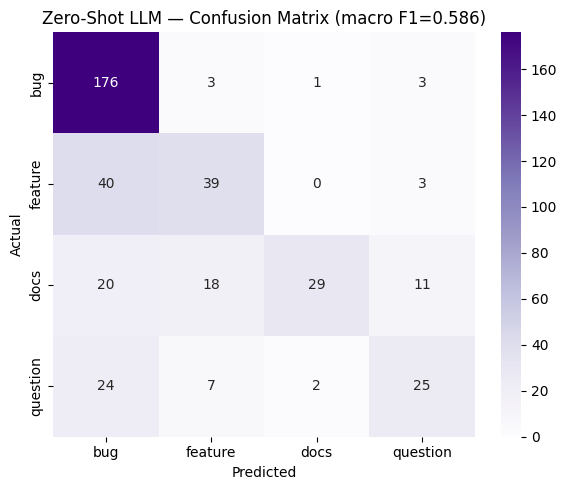

In [7]:
cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Zero-Shot LLM — Confusion Matrix (macro F1={macro_f1:.3f})')
plt.tight_layout()
plt.show()

## 5. Threshold Check

In [8]:
import yaml

with open('../../eval_thresholds.yaml') as f:
    thresholds = yaml.safe_load(f)

gates  = thresholds['classification']
report = classification_report(y_true, y_pred, labels=CLASSES, output_dict=True, zero_division=0)

print(f"Accuracy:  {accuracy:.3f}  (threshold: {gates['accuracy']})  {'PASS' if accuracy >= gates['accuracy'] else 'FAIL'}")
print(f"Macro F1:  {macro_f1:.3f}  (threshold: {gates['macro_f1']})  {'PASS' if macro_f1 >= gates['macro_f1'] else 'FAIL'}")
for cls in CLASSES:
    f1 = report.get(cls, {}).get('f1-score', 0)
    thr = gates['per_class'].get(cls, 0)
    print(f"  {cls:<10} F1: {f1:.3f}  (threshold: {thr})  {'PASS' if f1 >= thr else 'FAIL'}")

Accuracy:  0.671  (threshold: 0.6)  PASS
Macro F1:  0.586  (threshold: 0.6)  FAIL
  bug        F1: 0.795  (threshold: 0.55)  PASS
  feature    F1: 0.523  (threshold: 0.5)  PASS
  docs       F1: 0.527  (threshold: 0.85)  FAIL
  question   F1: 0.500  (threshold: 0.35)  PASS


## 6. Summary

Record these numbers in `ml/compare.ipynb` for the final comparison table.

In [9]:
per_class_f1 = {cls: round(report.get(cls, {}).get('f1-score', 0), 4) for cls in CLASSES}

print('=== LLM Zero-Shot Results (copy to compare.ipynb) ===')
print(f'accuracy   = {accuracy:.4f}')
print(f'macro_f1   = {macro_f1:.4f}')
print(f'per_class  = {per_class_f1}')
print(f'test_n     = {len(valid)}')

=== LLM Zero-Shot Results (copy to compare.ipynb) ===
accuracy   = 0.6708
macro_f1   = 0.5863
per_class  = {'bug': 0.7946, 'feature': 0.5235, 'docs': 0.5273, 'question': 0.5}
test_n     = 401
